## Problem

Solve $$-u''(x) + αu(x)^3 + V(x)u(x) = f(x)$$ 
with $u(0) = u(1), u'(0) = u'(1)$

### We formulate an equivalent problem: 
 Minimize a functional for which $$-u''(x) + αu(x)^3 + V(x)u(x) - f(x)$$ is the gradient. 

*Why*: The optimality requires the gradient to be 0, so when we optimize the functional, we get a 0 gradient 'point', which means $-u''(x) + αu(x)^3 + V(x)u(x) - f(x) = 0$.

### What is the functional to optimize: 
$ E(u) = \int_0^1 [\frac{1}{2}u'(x)^2 + \frac{α}{4} u(x)^4 + \frac{V(x)}{2} u(x)^2 - f(x)u(x)] dx$


# Implementation

### Hyperparameters

In [3]:
# N - the space discretization bin count
N = 100
# Returns a N equally distanced points from a to b.
function linspace(a::Number, b::Number, N::Integer)
    h = (b-a)/N
    collect(a:h:b-h)
end

xx = linspace(0, 1, N)

100-element Vector{Float64}:
 0.0
 0.01
 0.02
 0.03
 0.04
 0.05
 0.06
 0.07
 0.08
 0.09
 ⋮
 0.91
 0.92
 0.93
 0.94
 0.95
 0.96
 0.97
 0.98
 0.99

### Problem Parameters

In [4]:
# u - unknown function to find
u_exact = sin.(2pi .*xx)

# α - a real
α = 1

# V(x) - a function
V = 1.0 .+ 0.5 .* cos.(2π .* xx)

# f(x) - a function

100-element Vector{Float64}:
 1.5
 1.499013364214136
 1.496057350657239
 1.4911436253643444
 1.4842915805643155
 1.4755282581475768
 1.4648882429441257
 1.4524135262330098
 1.4381533400219317
 1.4221639627510076
 ⋮
 1.4221639627510076
 1.4381533400219317
 1.4524135262330098
 1.4648882429441255
 1.4755282581475768
 1.4842915805643155
 1.4911436253643444
 1.4960573506572388
 1.499013364214136

We use the u_exact and the other parameters to find an f that verifies the pde
$$f(x) = -u''(x) + αu(x)^3 + V(x)u(x) = 4π^2sin(2πx) + \alpha sin(2πx)^3 + sin(2πx) + 0.5cos(2πx)sin(2πx)$$

In [5]:
f = 4π^2*sin.(2π .* xx) + α .* u_exact.^3 + V .* u_exact

100-element Vector{Float64}:
   0.0
   2.5732417404937373
   5.137432226713647
   7.683509528420146
  10.202392164056418
  12.684973755413084
  15.122122801866846
  17.50468896034407
  19.823516957567467
  22.069468954786373
   ⋮
 -22.06946895478636
 -19.823516957567467
 -17.504688960344048
 -15.122122801866881
 -12.684973755413093
 -10.202392164056443
  -7.683509528420149
  -5.137432226713664
  -2.573241740493733

### Visualizations

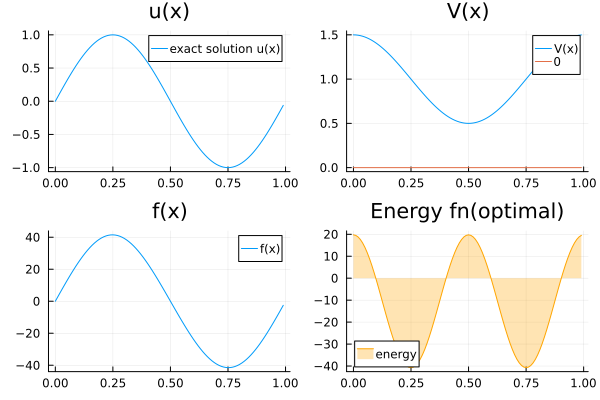

In [ ]:
using Plots

u_plot = plot(xx, u_exact, label="exact solution u(x)")
V_plot = plot(xx, [V zeros(N)], 
    labels = ["V(x)" "0"]
)
f_plot = plot(xx, f, label = "f(x)")

## Energy functional
# E(u) = /int_0^1 [1/2 * u'(x)^2 + α/4 * u(x)^4 + V(x)/2 * u(x)^2 - f(x)u] dx
e = 1/2 * (2π .* cos.(2π .*xx)).^2 + α/4 .* u_exact.^4 + V./2 .* u_exact.^2 - f .* u_exact
E = sum(e)/N 
energy_plot = plot(xx, e, label="energy",
fillrange = 0, fillalpha = 0.3, fillcolor = :orange, color= :orange)


plot(u_plot, V_plot, f_plot, energy_plot, layout=(2,2), titles=["u(x)" "V(x)" "f(x)" "Energy fn(optimal)"])

## Optimization

*From here we suppose u in unknown and try to find a u that optimizes the functional*

Because of the discretization it comes back to a N dimensional optimization problem

**Astuces:**

u' can be calculated the following ways: 
- $u'(0) = u'(1)$ condition prompts us to have derivative equal from both ways approaching so we can have 
    $$ u'_i = \frac{u_{i+1} - u_{i-1} }{2h}$$
where the indexing wraps around modulo N
- **Spectral approach**
    We use the DFT, and the derivative in fourier space is easier to calculate

### Method One

#### Derivatives

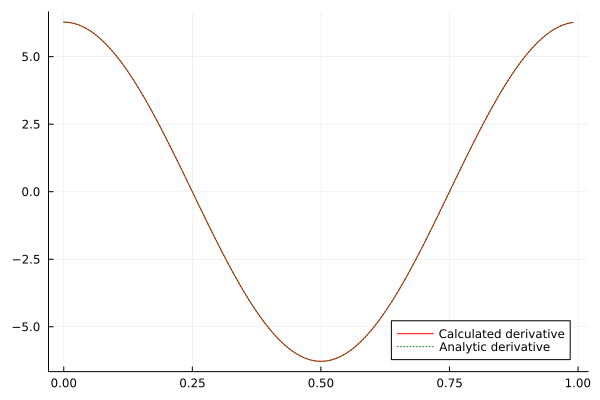

In [14]:
function diff(N)
    # We need to calculate the u', which is just a linear operator in this case, so we construct a matrix to do that
    D = zeros(N, N)
    h = 1/N
    for i in 1:N
        D[i, mod(i, N)+1] = 1/2h
        D[i, mod(i-2, N)+1 ] = -1/2h
    end
    return D
end
du_calc = diff(N) * u_exact
du_exact = 2π .* cos.(2π .* xx)
# du_calc_plot =plot(xx, du_calc)
# du_exact_plot = plot(xx, du_exact) 
du_plot = plot(xx, [du_calc du_exact], labels=["Calculated derivative" "Analytic derivative"], color=[:red :green], ls= [:solid :dot])
# plot(du_calc_plot, du_exact_plot, du_plot, layout = (2, 2))


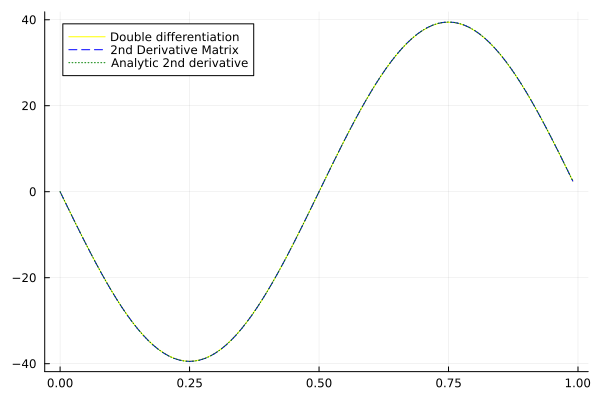

In [18]:
## Second derivative
function diff2(N)
    D2 = zeros(N, N)
    h = 1/N
    for i in 1:N
        D2[i, i] = -2/(h^2)
        D2[i, mod(i, N)+1] = 1/(h^2)
        D2[i, mod(i-2, N) +1] = 1/(h^2)
    end
    return D2
end
d2u = diff(N) * du_calc
d2u_form = diff2(N) * u_exact
d2u_exact = -4π^2 .* sin.(2π .* xx)
plot(xx, [d2u d2u_form d2u_exact], labels=["Double differentiation" "2nd Derivative Matrix" "Analytic 2nd derivative"], color=[:yellow :blue :green], ls= [:solid :dash :dot])


#### Newtons Method

In [33]:
function F(u, α = α,V = V,  f=f)
    return -diff2(N)*u + α .* u.^3 + V .* u - f
end

F (generic function with 4 methods)

In [34]:
function Newton_solve(α, V, f, method, n_iter)
    u = zeros(N)
    for i in 1:n_iter
        res = F(u)
        J = method(u)
        step = J \ res
        u = u - step
    end
end

Newton_solve (generic function with 2 methods)

#### Methods for calculating the Jacobian

**Finite differences**
$$ Jv = \frac{F (u + \varepsilon v) − F (u)}{\varepsilon}$$

In [35]:
function finite_differences(u, α = α, V = V, f = f; eps=1e-10) 
    J = zeros(N, N)
    for i in 1:N
        v = zeros(N)
        v[i] = 1
        J[i] = (F(u + eps * v) - F(u)) / eps
    end
    return J.T
end

finite_differences (generic function with 4 methods)

**Forward Mode AD**

**Reverse Mode AD**

#### Evaluating performance

In [38]:
Newton_solve(α, V, f, finite_differences, 10)

MethodError: MethodError: Cannot `convert` an object of type Vector{Float64} to an object of type Float64
The function `convert` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  convert(::Type{Float64}, !Matched::Measures.AbsoluteLength)
   @ Measures ~/.julia/packages/Measures/4QYr0/src/length.jl:12
  convert(::Type{T}, !Matched::T) where T<:Number
   @ Base number.jl:6
  convert(::Type{T}, !Matched::Number) where T<:Number
   @ Base number.jl:7
  ...


### Spectral Method